In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout

In [2]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")

In [3]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
df = pd.read_csv('crypto_combine.csv')

In [4]:
df.head()

,Crypto,Date,Open,High,Low,Close
0,BTC,12/31/19,7254.0,7309.0,7132.0,7171.0
1,BTC,12/30/19,7402.0,7430.0,7217.0,7254.0
2,BTC,12/29/19,7334.0,7529.0,7295.0,7402.0
3,BTC,12/28/19,7235.0,7359.0,7235.0,7334.0
4,BTC,12/27/19,7208.0,7267.0,7087.0,7235.0


In [5]:
df.tail()

,Crypto,Date,Open,High,Low,Close
7894,XRP,1/5/19,0.36,0.36,0.35,0.36
7895,XRP,1/4/19,0.36,0.36,0.35,0.36
7896,XRP,1/3/19,0.37,0.38,0.35,0.36
7897,XRP,1/2/19,0.36,0.37,0.36,0.37
7898,XRP,1/1/19,0.35,0.36,0.34,0.36


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7899 entries, 0 to 7898
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Crypto  7899 non-null   object 
 1   Date    7899 non-null   object 
 2   Open    7899 non-null   float64
 3   High    7899 non-null   float64
 4   Low     7899 non-null   float64
 5   Close   7899 non-null   float64
dtypes: float64(4), object(2)
memory usage: 370.4+ KB


In [7]:
# Convert Date and Sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# Label Encoding for Crypto names
le = LabelEncoder()
df['Crypto_Enc'] = le.fit_transform(df['Crypto'])

# Feature Engineering for Student 2
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)
df['Daily_Range'] = df['High'] - df['Low']

features = ['Open', 'High', 'Low', 'Crypto_Enc', 'DayOfWeek', 'Daily_Range']
X = df[features]
y = df['Close']

# Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

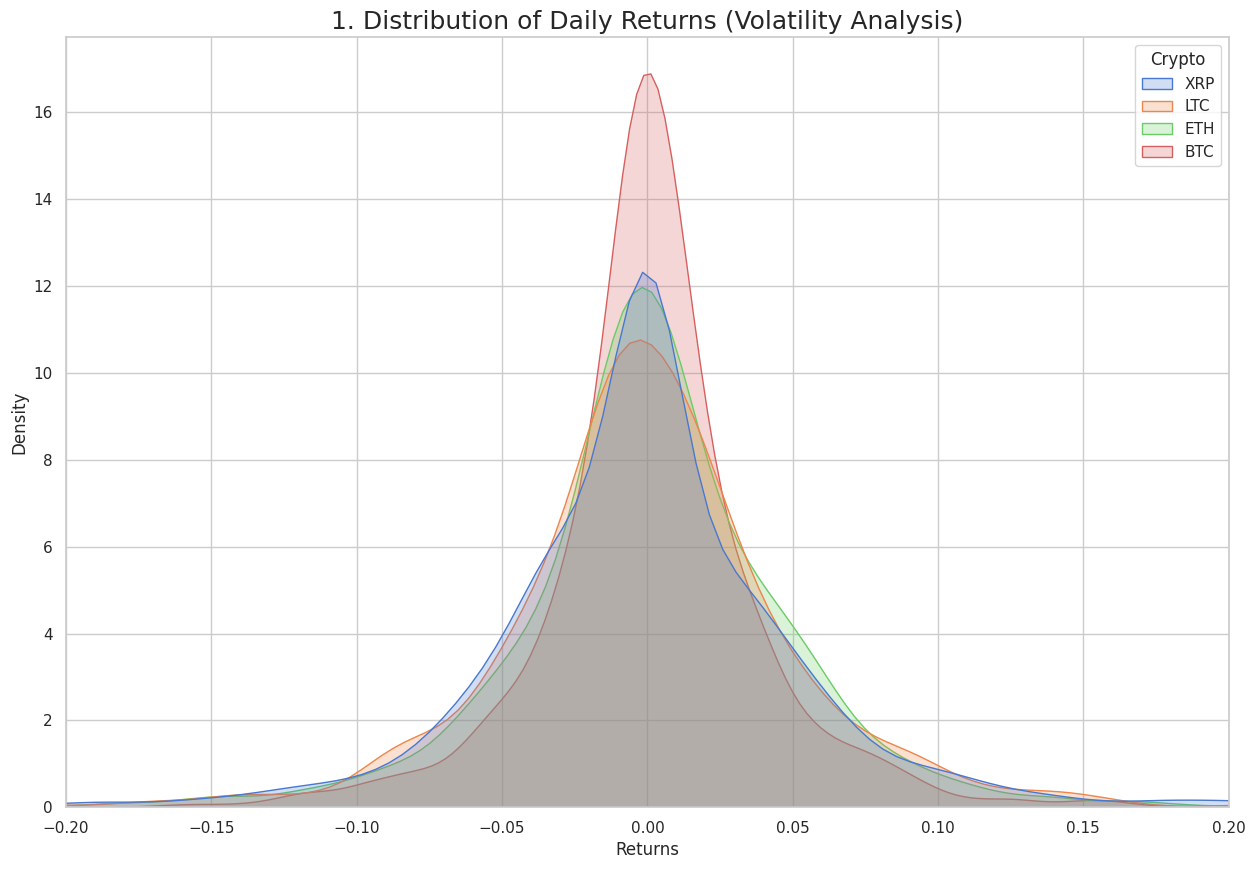

In [8]:
plt.figure(figsize=(15, 10))
df['Returns'] = df.groupby('Crypto')['Close'].pct_change()
sns.kdeplot(data=df, x='Returns', hue='Crypto', fill=True, common_norm=False)
plt.title('1. Distribution of Daily Returns (Volatility Analysis)', fontsize=18)
plt.xlim(-0.2, 0.2)
plt.show()

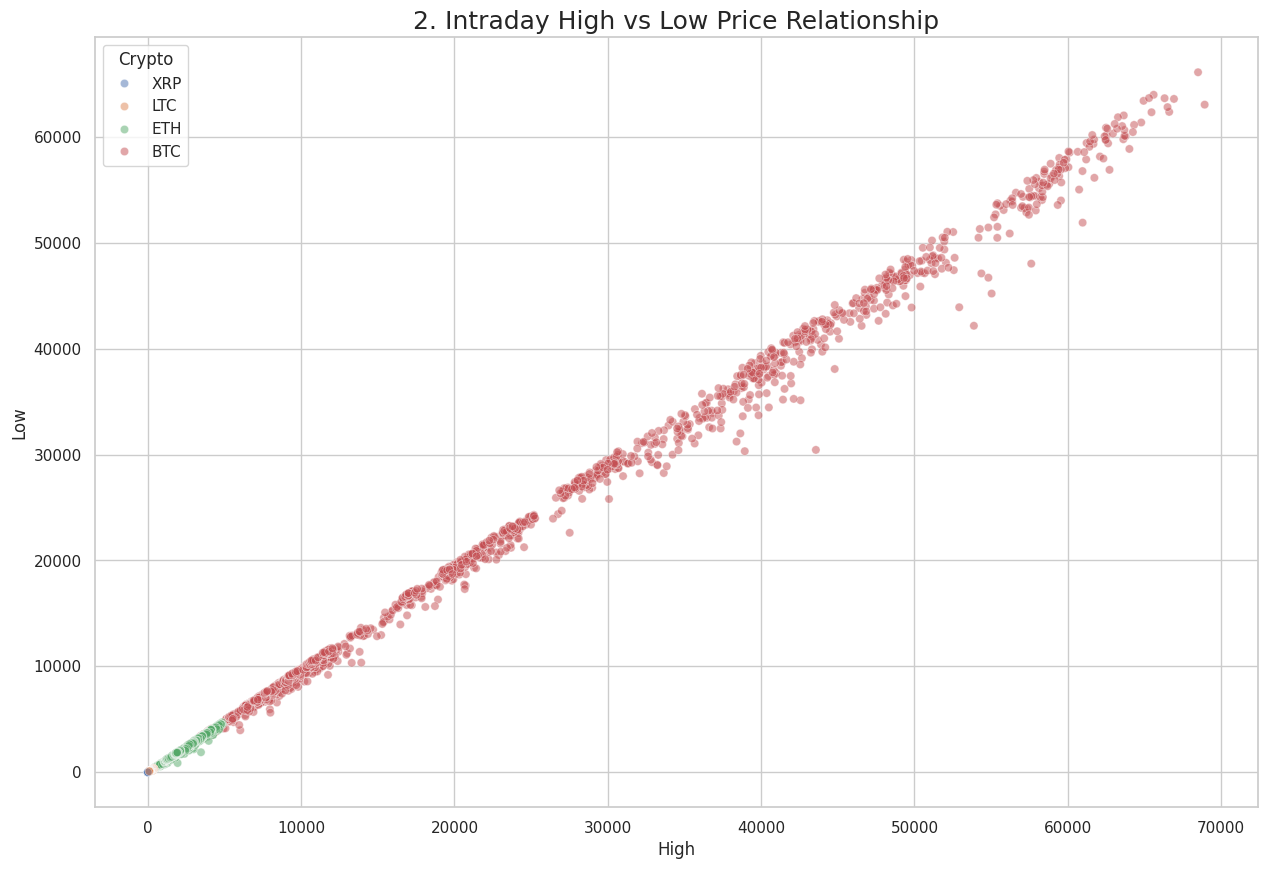

In [9]:
plt.figure(figsize=(15, 10))
sns.scatterplot(data=df, x='High', y='Low', hue='Crypto', alpha=0.5, palette='deep')
plt.title('2. Intraday High vs Low Price Relationship', fontsize=18)
plt.show()

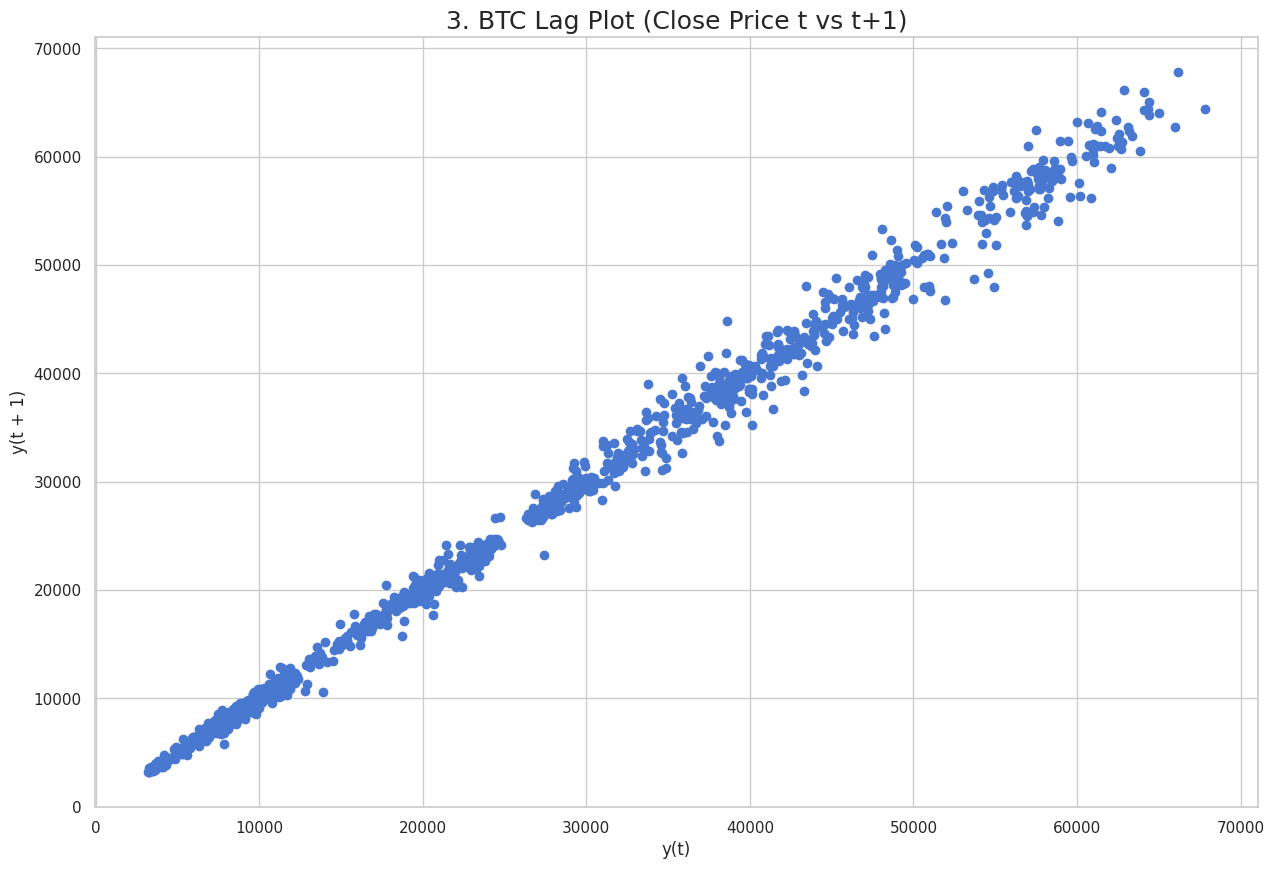

In [10]:
plt.figure(figsize=(15, 10))
pd.plotting.lag_plot(df[df['Crypto']=='BTC']['Close'], lag=1)
plt.title('3. BTC Lag Plot (Close Price t vs t+1)', fontsize=18)
plt.show()

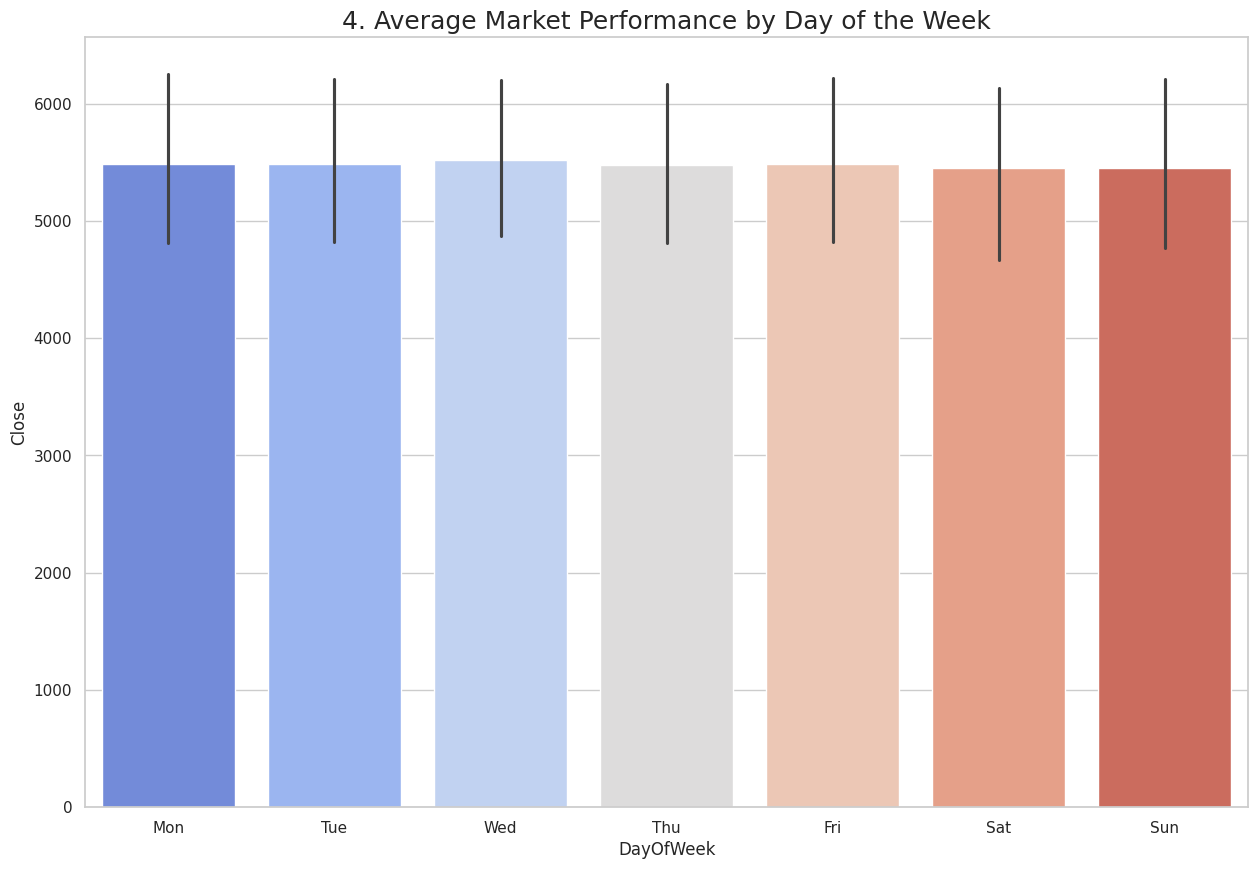

In [11]:
plt.figure(figsize=(15, 10))
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.barplot(x='DayOfWeek', y='Close', data=df, estimator=np.mean, palette='coolwarm')
plt.xticks(ticks=range(7), labels=day_names)
plt.title('4. Average Market Performance by Day of the Week', fontsize=18)
plt.show()

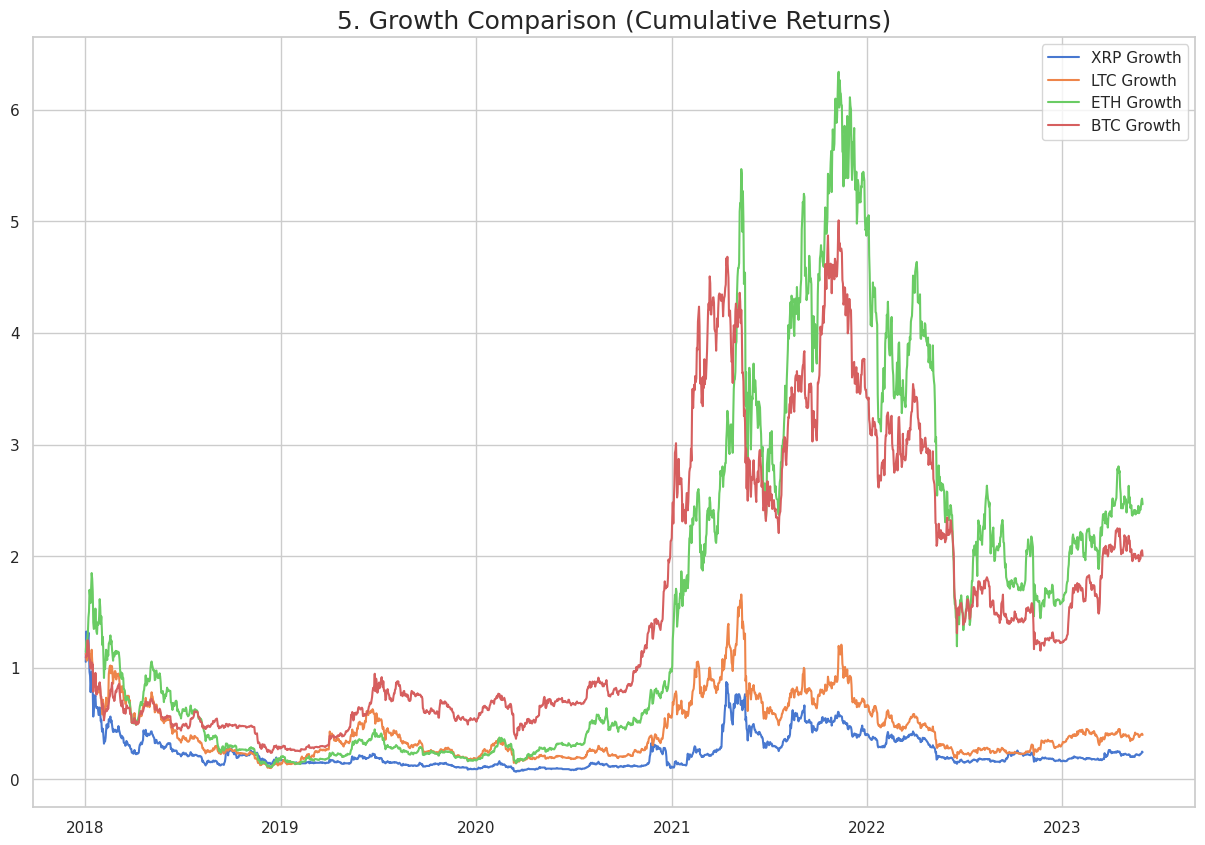

In [12]:
plt.figure(figsize=(15, 10))
for crypto in df['Crypto'].unique():
    subset = df[df['Crypto'] == crypto].copy()
    subset['CumReturn'] = (1 + subset['Close'].pct_change()).cumprod()
    plt.plot(subset['Date'], subset['CumReturn'], label=f'{crypto} Growth')
plt.title('5. Growth Comparison (Cumulative Returns)', fontsize=18)
plt.legend()
plt.show()

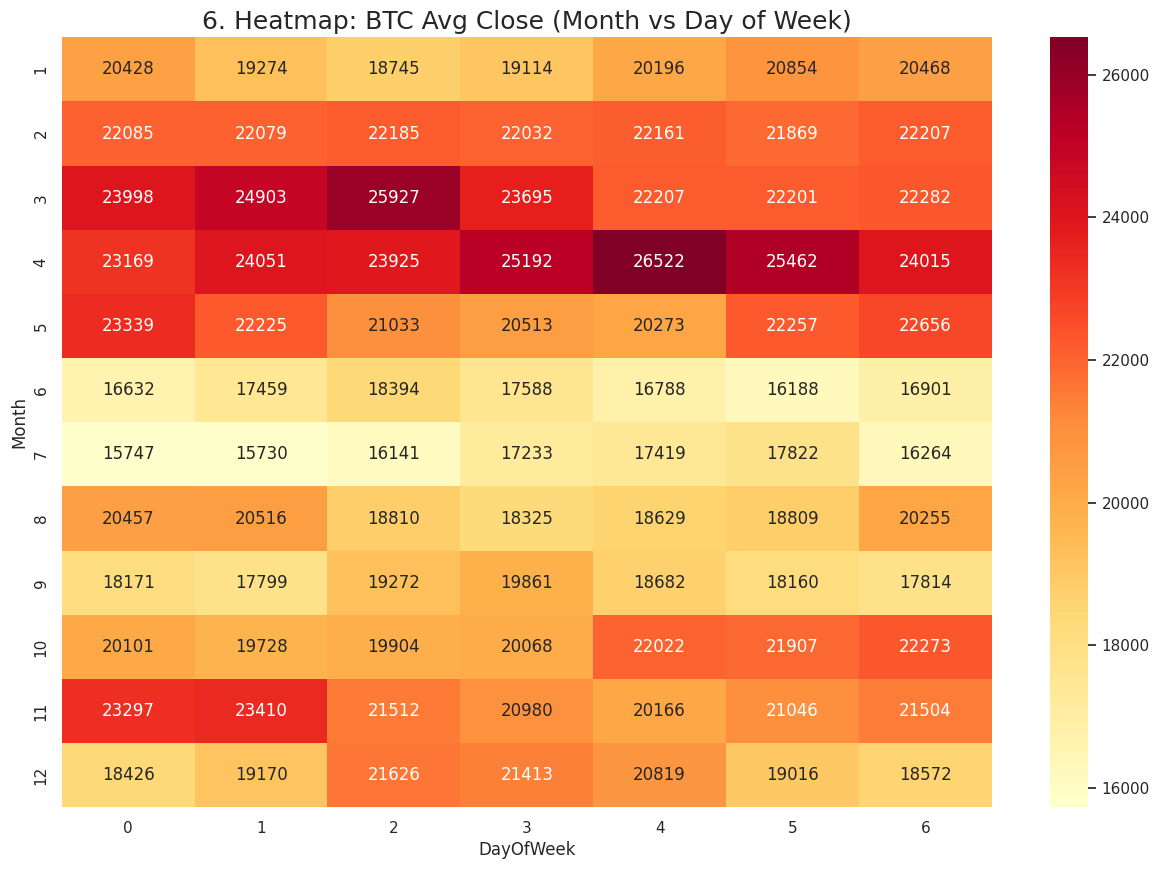

In [13]:
plt.figure(figsize=(15, 10))
btc_only = df[df['Crypto'] == 'BTC'].copy()
btc_only['Month'] = btc_only['Date'].dt.month
pivot = btc_only.pivot_table(values='Close', index='Month', columns='DayOfWeek', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='YlOrRd')
plt.title('6. Heatmap: BTC Avg Close (Month vs Day of Week)', fontsize=18)
plt.show()

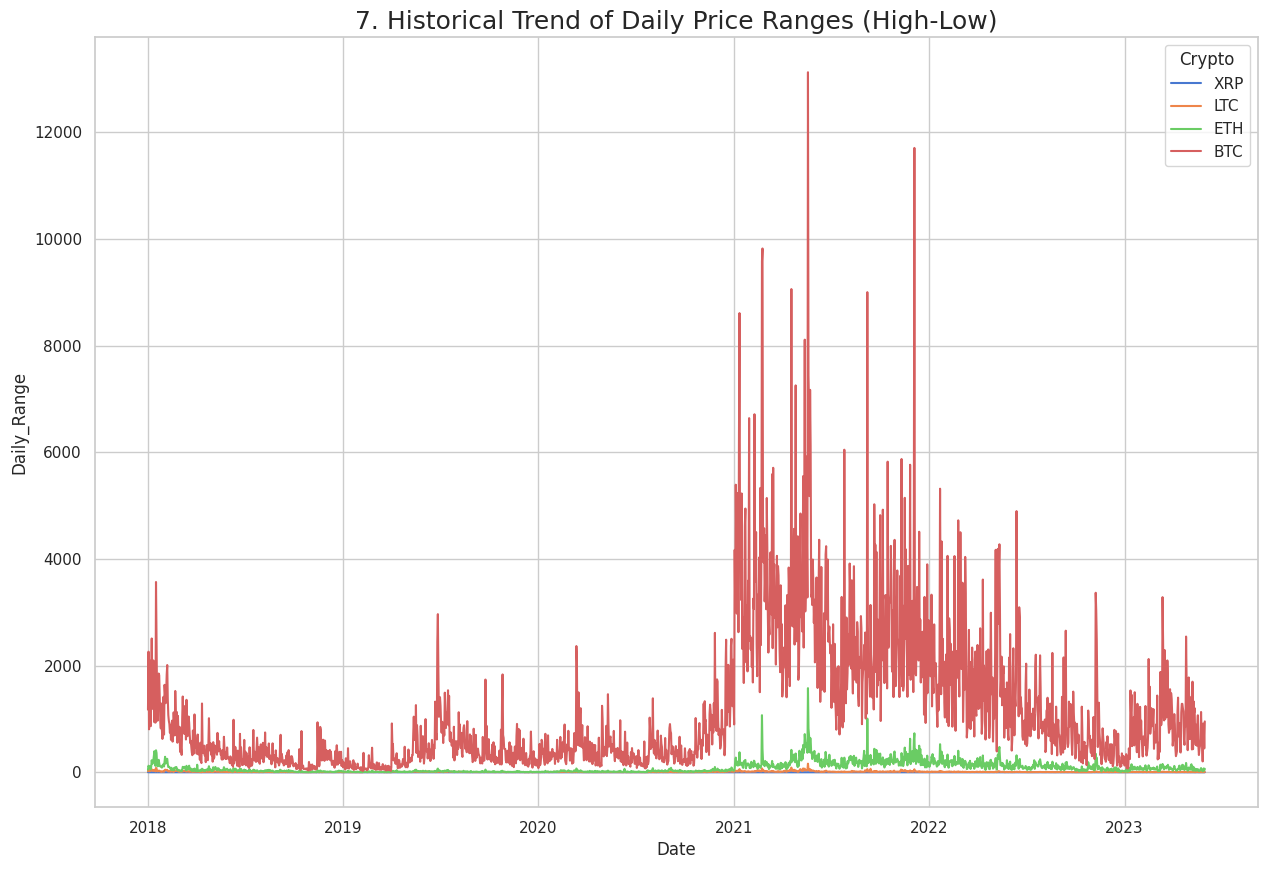

In [14]:
plt.figure(figsize=(15, 10))
sns.lineplot(data=df, x='Date', y='Daily_Range', hue='Crypto')
plt.title('7. Historical Trend of Daily Price Ranges (High-Low)', fontsize=18)
plt.show()

<Figure size 1500x1000 with 0 Axes>

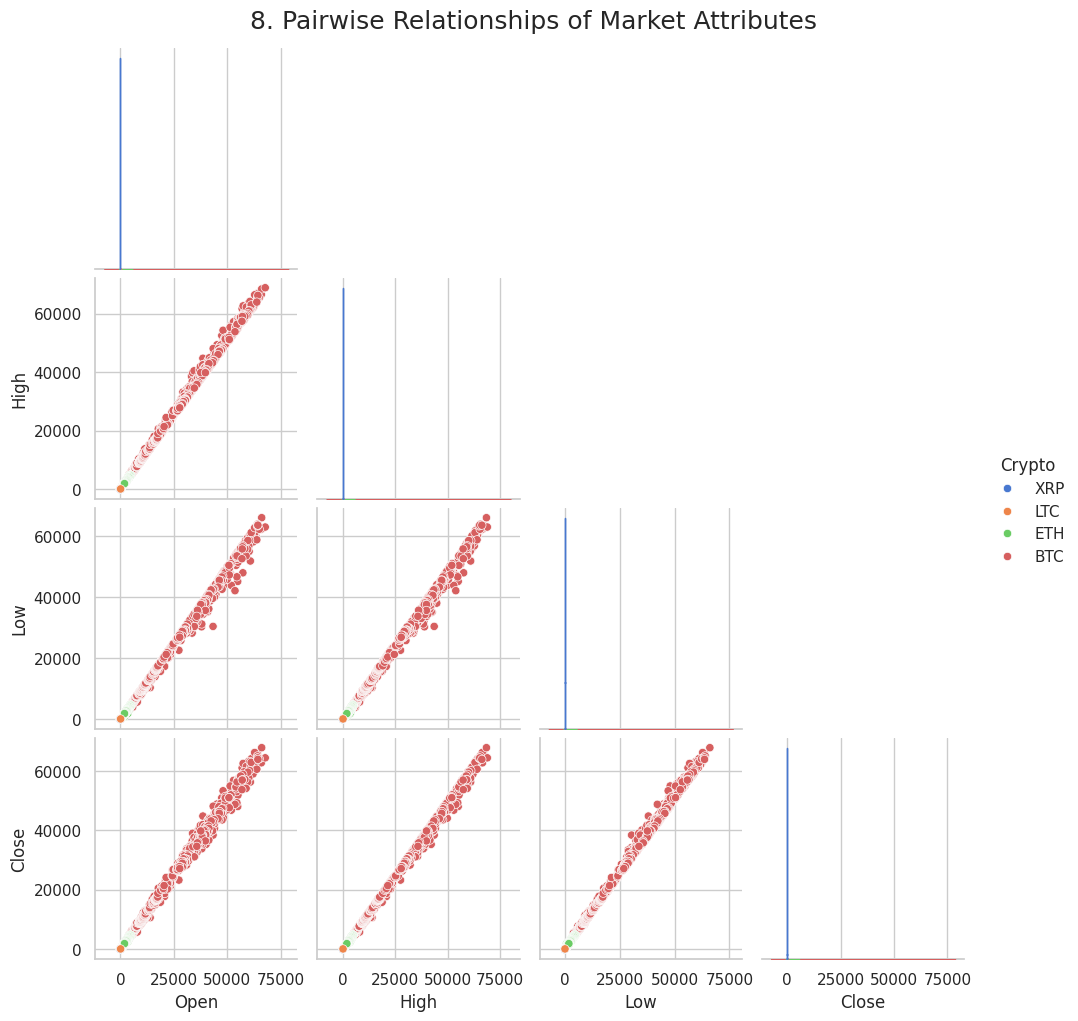

In [15]:
plt.figure(figsize=(15, 10))
sns.pairplot(df[['Open', 'High', 'Low', 'Close', 'Crypto']], hue='Crypto', corner=True)
plt.suptitle('8. Pairwise Relationships of Market Attributes', y=1.02, fontsize=18)
plt.show()

In [16]:
# ==========================================
# 3. MODELS: 2 ML AND 1 DL
# ==========================================

# --- ML Model 1: Gradient Boosting Regressor ---
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train.ravel())
gb_preds = gb_model.predict(X_test)

# --- ML Model 2: Support Vector Regressor (SVR) ---
svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
svr_model.fit(X_train, y_train.ravel())
svr_preds = svr_model.predict(X_test)

# --- DL Model: Gated Recurrent Unit (GRU) ---
X_train_gru = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_gru = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    GRU(25),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.fit(X_train_gru, y_train, epochs=15, batch_size=32, verbose=0)
gru_preds = gru_model.predict(X_test_gru)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [17]:
# ==========================================
# 4. EVALUATION & RANKING
# ==========================================

def calculate_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'R2 Score': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

results = [
    calculate_metrics(y_test, gb_preds, 'Gradient Boosting'),
    calculate_metrics(y_test, svr_preds, 'Support Vector Regressor'),
    calculate_metrics(y_test, gru_preds, 'GRU (Deep Learning)')
]

# Create Rank Table
rank_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
rank_df.index += 1
rank_df.index.name = 'Rank'

print("\n" + "="*40)
print("MODEL RANKING RESULTS")
print("="*40)
print(rank_df)


MODEL RANKING RESULTS
                         Model  R2 Score       MAE      RMSE
Rank                                                        
1            Gradient Boosting  0.999242  0.001632  0.004936
2          GRU (Deep Learning)  0.998614  0.004545  0.006675
3     Support Vector Regressor  0.780208  0.080943  0.084067


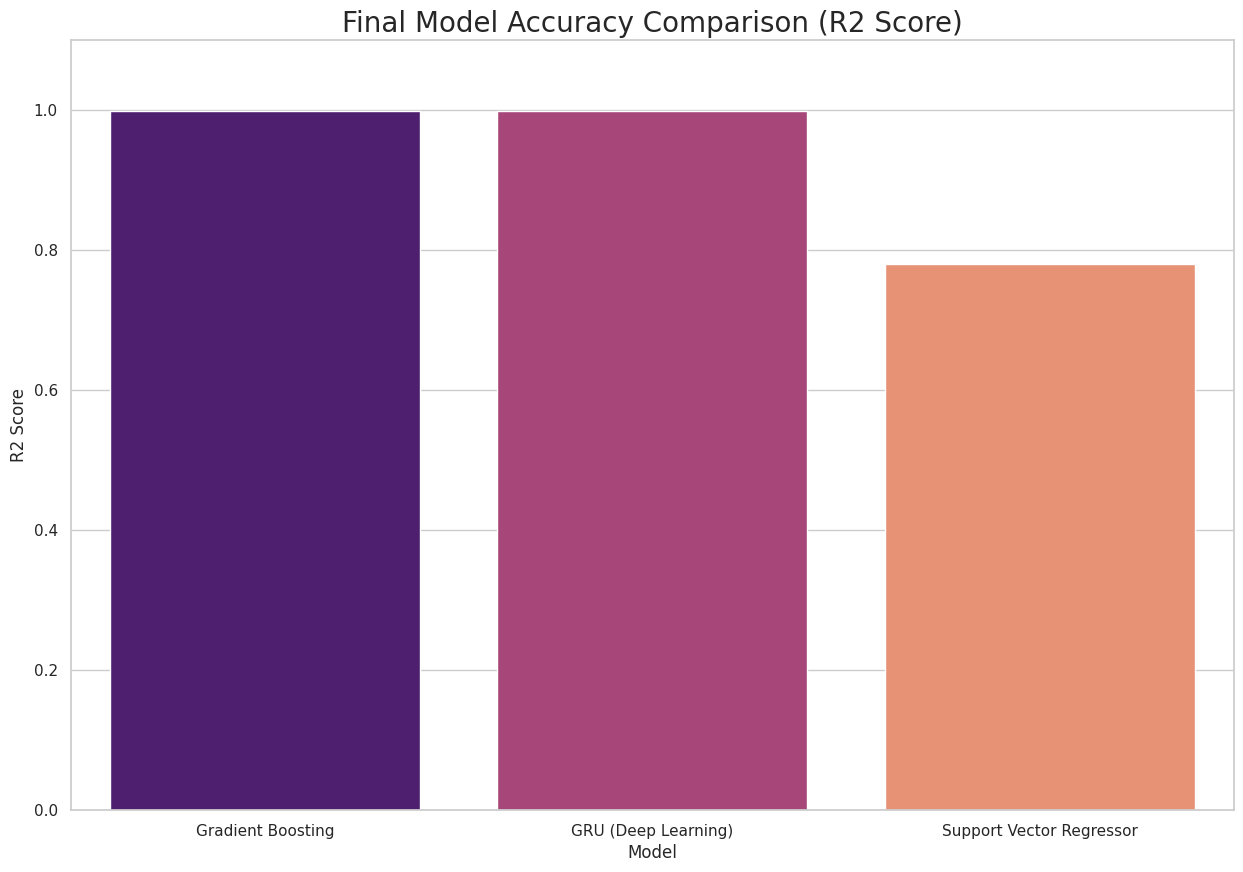

In [18]:
# Final Performance Chart
plt.figure(figsize=(15, 10))
sns.barplot(x='Model', y='R2 Score', data=rank_df, palette='magma')
plt.title('Final Model Accuracy Comparison (R2 Score)', fontsize=20)
plt.ylim(0, 1.1)
plt.show()